In [39]:
from enums.ScalingMethod import ScalingMethod
from enums.ResamplingMethod import ResamplingMethod
from model.XGBoostModel import XGBoostModel
from service.exportservice.ExportService import ExportService
from service.datasetservice.DatasetService import DatasetService
from model.ShallowNNModel import ShallowNNModel
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
database = "test"
with_features = True
scaling_method = None
resampling_method = None

In [41]:
dataset_service = DatasetService()
export_service = ExportService(database=database, collection="centralized")

In [42]:
x_all, y_all = dataset_service.get_subject_data(subject="all", with_features=with_features)
x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

In [43]:
 # 1. Initialize model, scaler and resampler
scaler = dataset_service.get_scaler(method=scaling_method)
resampler = dataset_service.get_resampler(method=resampling_method)

print(scaler, resampler)

None None


In [45]:
model = ShallowNNModel(scaler=scaler, resampler=resampler, input_shape=x_train.shape[1])
model.fit(x_train=x_train, y_train=y_train, run_info=dict())

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Epoch 1/100
Epoch 1/100
Epoch 1/100
Epoch 1/100
Epoch 1/100
1576/1576 - 8s - 5ms/step - accuracy: 0.6751 - loss: 0.6322 - val_accuracy: 0.6872 - val_loss: 0.6036 - learning_rate: 0.0010
Epoch 2/100
1576/1576 - 8s - 5ms/step - accuracy: 0.6747 - loss: 0.6312 - val_accuracy: 0.6905 - val_loss: 0.5918 - learning_rate: 0.0010
Epoch 2/100
1576/1576 - 8s - 5ms/step - accuracy: 0.6780 - loss: 0.6345 - val_accuracy: 0.6942 - val_loss: 0.5933 - learning_rate: 0.0010
Epoch 2/100
1576/1576 - 8s - 5ms/step - accuracy: 0.6769 - loss: 0.6310 - val_accuracy: 0.6893 - val_loss: 0.5941 - learning_rate: 0.0010
Epoch 2/100
1576/1576 - 8s - 5ms/step - accuracy: 0.6765 - loss: 0.6300 - val_accuracy: 0.6909 - val_loss: 0.6235 - learning_rate: 0.0010
Epoch 2/100
1576/1576 - 7s - 4ms/step - accuracy: 0.6853 - loss: 0.5949 - val_accuracy: 0.6917 - val_loss: 0.5822 - learning_rate: 0.0010
Epoch 3/100
1576/1576 - 7s - 4ms/step - accuracy: 0.6879 - loss: 

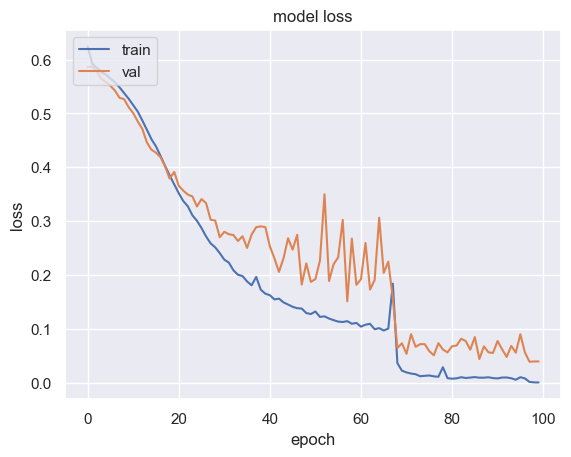

In [46]:
history = model.get_fitted_model().named_steps["clf"].history_

plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [47]:
pred_train = model.predict(x=x_train)
scores_train, _ = model.evaluate(pred=pred_train, y_true=y_train)
pred_test = model.predict(x=x_test)
scores_test, cm = model.evaluate(pred=pred_test, y_true=y_test)
print(scores_test)

2462/2462 - 1s - 549us/step
616/616 - 0s - 576us/step
{'accuracy': 0.9936024371667936, 'recall': 0.9919380844888745, 'precision': 0.9877970456005138, 'f1': 0.9898632341110217, 'confusion_matrix': {'tp': 6152, 'tn': 13417, 'fp': 50, 'fn': 76}}
